# Multimodal Source Power co-Modulation (mSPoC)

In [ ]:
# Setup & Environment Initialization
# ==============================================================================
# Objective: mSPoC combining MEG with DOT time series.
%load_ext autoreload
%autoreload 2

import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal as signal
import xarray as xr
from scipy.linalg import eigh
from sklearn.cross_decomposition import CCA
from cedalion.sigdecomp.multimodal.mspoc import mSPoC

# Custom visualizers and helper utilities
from utils import (
    calculate_single_trial_snr,
    collect_subject_snr,
    compute_spatial_pattern,
    plot_block_average_dot,
    plot_block_average_mspoc,
    plot_brain_maps_grid,
    plot_reconstructed_sources,
    plot_spatial_patterns,
    plot_temporal_weights,
    prepare_training_data,
)

def zscore(x: np.ndarray, axis: int = 0) -> np.ndarray:
    """Computes z-score normalization with zero-variance protection."""
    std = np.std(x, axis=axis, keepdims=True)
    std[std == 0.0] = 1e-8
    return (x - np.mean(x, axis=axis, keepdims=True)) / std

In [ ]:
 # Prepare data for mSPoC
SUBJECT = "voja"
MEAS_ID = "S3-2-finger"
BAD_TRIAL_INDICES = []
meg_fs = 100
original_fs = 5
dt=0.5

meg_nc_fname = OUTPUT_DIR / f"{MEAS_ID}_MEG.nc"
fnirs_nc_fname = OUTPUT_DIR / f"{MEAS_ID}_FNIRS.nc"
parcel_list_fname = OUTPUT_DIR / f"parcel_list_{MEAS_ID}.json"

X = xr.open_dataarray(meg_nc_fname)
Y = xr.open_dataarray(fnirs_nc_fname)

with open(parcel_list_fname, "r") as f:
    parcel_list = json.load(f)

print(f"  - Loaded MEG DataArray (X): {X.shape} {X.dims}")
print(f"  - Loaded fNIRS DataArray (Y): {Y.shape} {Y.dims}")
print(f"  - Loaded Sensitive Parcels Count: {len(parcel_list)}")

In [ ]:
new_parcel_names = [name.replace('_LHH', '_LH') for name in fnirs_final.parcel.values]
Y = Y.assign_coords(parcel=new_parcel_names)

X = X.sel(parcel=parcel_list) # ensure the order of parcels matches
Y = Y.sel(parcel=parcel_list) 

In [ ]:
time_shifts = np.arange(0, 15, dt ) # The result is different when change min, max and dt!

#Identify Good Trials
total_trials = len(stim) - 1  # the last row is excluded
good_trials = [t for t in range(total_trials) if t not in BAD_TRIAL_INDICES]

X_train_hbo, Y_train_hbo = prepare_training_data(Y.sel(chromo='HbO'), X, good_trials)
X_train_hbr, Y_train_hbr = prepare_training_data(Y.sel(chromo='HbR'), X, good_trials)


In [ ]:

# Initialize and fit the model on the clean trials
full_model_hbo = mSPoC(
    N_components=2, 
    N_restarts=15,   
    max_iter=1000,   
    tol=1e-4,
    scale=True,
    time_shifts=time_shifts,
    shift_source=True,
)


full_model_hbo.fit(X_train_hbo, Y_train_hbo, featureX_name="parcel", featureY_name="parcel")

Sx_hbo, Sy_hbo = full_model_hbo.transform(X_train_hbo, Y_train_hbo)

In [ ]:
print(f"Optimal Time Shift: {full_model.optimal_shift[0]:.1f} {full_model.optimal_shift[1]:.1f}")

Optimal Time Shift: 4.5 4.5


In [ ]:

full_model_hbr = mSPoC(
    N_components=2, 
    N_restarts=15,   
    max_iter=1000,   
    tol=1e-4,
    scale=True,
    time_shifts=time_shifts,
    shift_source=True,
)


full_model_hbr.fit(X_train_hbr, Y_train_hbr, featureX_name="parcel", featureY_name="parcel")

Sx_hbr, Sy_hbr = full_model_hbr.transform(X_train_hbr, Y_train_hbr)

print(f"Optimal Time Shift HbR models: {full_model_hbr.optimal_shift[0]:.1f}, {full_model_hbr.optimal_shift[1]:.1f} seconds")


## Check the direction of latent sources

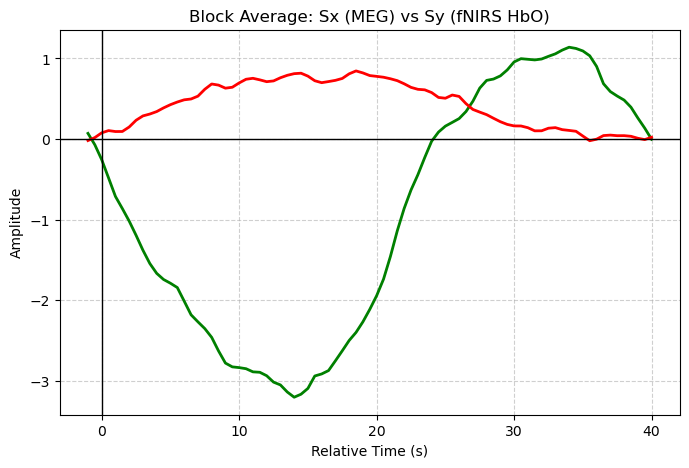

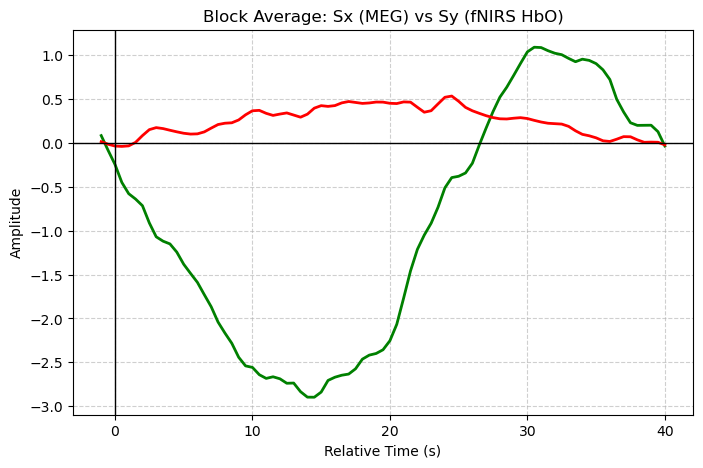

In [ ]:
plot_block_average_mspoc(Sx_hbo, Sy_hbo, stim,  'Sx1', 'Sy1', color_x="green", color_y="red")
plot_block_average_mspoc(Sx_hbo, Sy_hbo, stim,  'Sx2', 'Sy2', color_x="green", color_y="red")


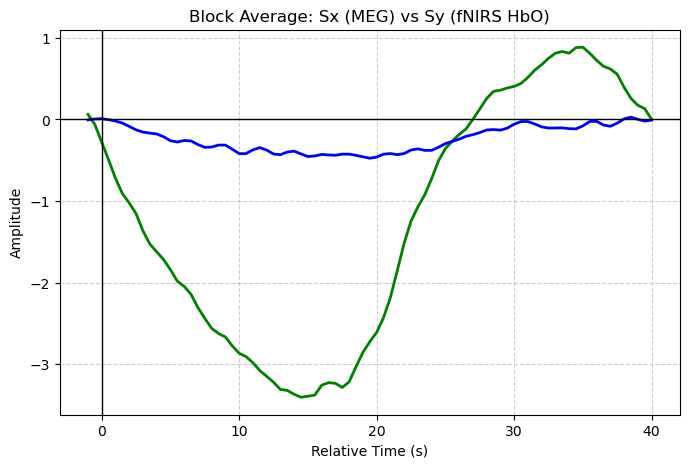

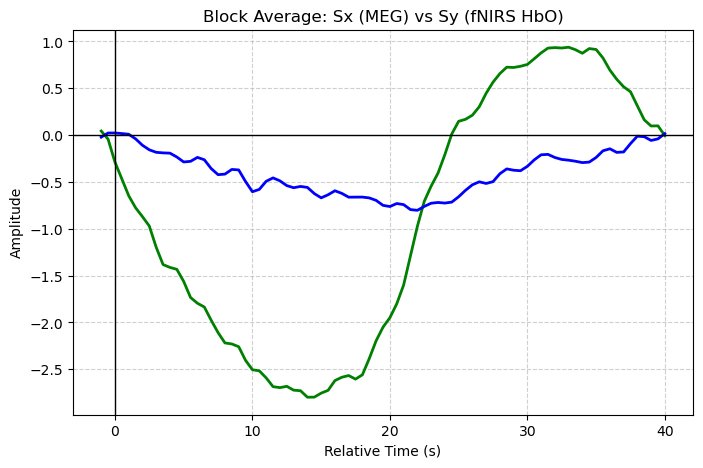

In [ ]:
plot_block_average_mspoc(Sx_hbr, Sy_hbr, stim,  'Sx1', 'Sy1', color_x="green", color_y="blue")
plot_block_average_mspoc(Sx_hbr, Sy_hbr, stim,  'Sx2', 'Sy2', color_x="green", color_y="blue")


## Figure 5(A)
Conventional anatomical prior (M1)

In [ ]:
# Select the specific ROI using xarray
meg_conv = X.sel(parcel="SomMotA_13_LH")
hbo_conv = Y.sel(parcel="SomMotA_13_LH", chromo="HbO")
hbr_conv = Y.sel(parcel="SomMotA_13_LH", chromo="HbR")

# Compute epoch-based variance for MEG (Matches the fNIRS time grid)
epoch_len = len(meg_conv) // len(hbo_conv)

# Subtract the mean across time for each parcel/channel
meg_values = meg_conv.values - meg_conv.values.mean(axis=0)

# Calculate power as variance within epochs
# Source power is approximated by the variance within these intervals.
p_power = np.array([
    np.var(meg_values[j * epoch_len : (j + 1) * epoch_len]) 
    for j in range(len(hbo_conv))
])

# Apply Z-score 
# This brings all modalities to a comparable scale for optimization
sx_norm_arr = zscore(p_power)
sy_hbo_norm_arr = zscore(hbo_conv.values)
sy_hbr_norm_arr = zscore(hbr_conv.values)

time_coords = hbo_conv.time.values

sx_norm = xr.DataArray(sx_norm_arr, coords=[("time", time_coords)])
sy_hbo_norm = xr.DataArray(sy_hbo_norm_arr, coords=[("time", time_coords)])
sy_hbr_norm = xr.DataArray(sy_hbr_norm_arr, coords=[("time", time_coords)])

# Define time masks and slice the normalized data
valid_times = hbo_conv.time.values
mask_times = valid_times[valid_times <= 500]

meg_sliced = sx_norm.sel(time=slice(mask_times[0], mask_times[-1]))
hbo_sliced = sy_hbo_norm.sel(time=slice(mask_times[0], mask_times[-1]))
hbr_sliced = sy_hbr_norm.sel(time=slice(mask_times[0], mask_times[-1]))
# Get time coordinates and shift them to start at 0
raw_time = hbo_sliced.time.values
continuous_time = raw_time - raw_time[0] 

# Plotting combined Figure 
fig, ax = plt.subplots(figsize=(5, 4))

# Plot all three signals together
ax.plot(continuous_time, meg_sliced, color='green', linewidth=1,alpha=0.5, label=r"MEG Power ")
ax.plot(continuous_time, hbo_sliced, color='red', linewidth=2, alpha=0.7, label=r"HbO ")
ax.plot(continuous_time, hbr_sliced, color='blue', linewidth=2, alpha=0.6, label=r"HbR ")

# Formatting and styling
ax.set_title("Conventional anatomical prior", fontsize=14, fontweight='bold')
ax.set_xlabel("Time (s)", fontsize=14)
ax.set_ylabel("Normalized Units", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(-5, 5) 
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper center',bbox_to_anchor=(0.5, -0.3), fontsize=11,  ncol=2, frameon=False)

# Set dynamic x-limits based on your preferred maximum time tracking
max_time = 300
ax.set_xlim(0, max_time)

# Custom vertical line & grid handling at every 40-second interval
epoch_ticks = np.arange(0, max_time + 1, 40)
v_lines = np.arange(40, max_time, 40)

ax.set_xticks(epoch_ticks)
for xc in v_lines:
    ax.axvline(x=xc, color='gray', linestyle=':', alpha=0.7, linewidth=1.5)

plt.tight_layout()
plt.show()

## Figure 5(B), (D)
Figure 5(D): Source Power Comodulation of Reconstructed Neural and Vascular Sources.
Scatter plots illustrate the coupling between the extracted neural driver (Sx1​) and the vascular target (Sy1​) for the HbO and HbR Modality. Each data point represents the relationship within a single epoch from the concatenated "good" trial dataset. The x-axis denotes the normalized oscillatory power (z-score) of the neural source isolated from MEG data, reconstructed after applying optimal spatial filters (Wx​) and temporal weights (Wt​) to synchronize with the hemodynamic response. The y-axis represents the normalized concentration of the vascular component isolated via mSPoC spatial filtering (Wy​) of the DOT signal.


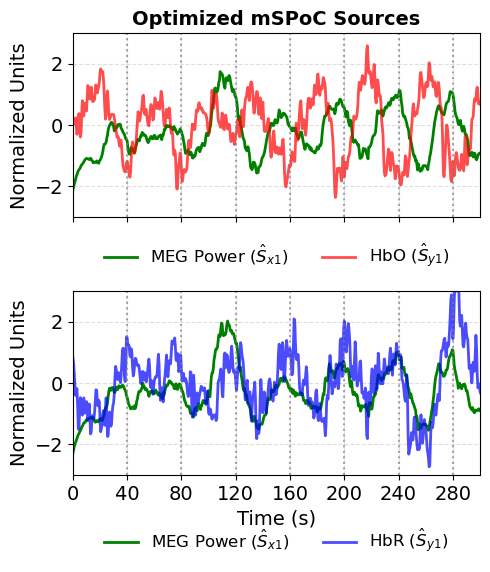

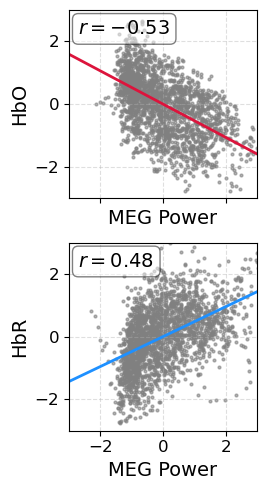

In [ ]:
plot_reconstructed_sources(Sx_hbo, Sy_hbo, Sx_hbr, Sy_hbr, component=1)

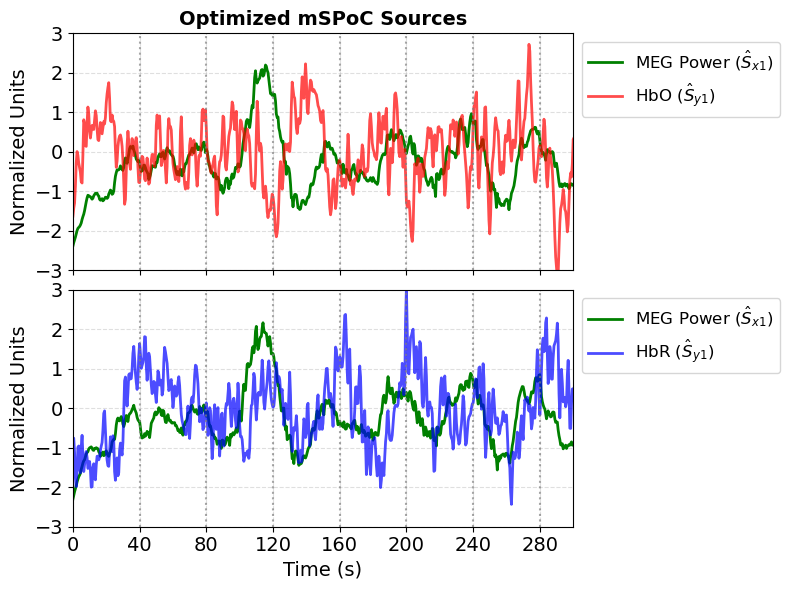

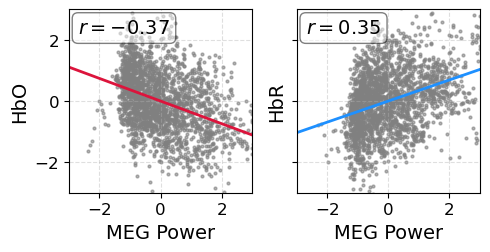

In [ ]:
plot_reconstructed_sources(Sx_hbo, Sy_hbo, Sx_hbr, Sy_hbr, component=2)

## Figure 5(C)
Temporal Plot

In [ ]:
wt_hbo_c1 = full_model_hbo.Wt.sel(mSPoC_T='St1').values
wt_hbr_c1 = full_model_hbr.Wt.sel(mSPoC_T='St1').values
optimal_lag_hbo_c1 = full_model_hbo.optimal_shift[0]
optimal_lag_hbr_c1 = full_model_hbr.optimal_shift[0]

wt_hbo_c2 = full_model_hbo.Wt.sel(mSPoC_T='St2').values
wt_hbr_c2 = full_model_hbr.Wt.sel(mSPoC_T='St2').values
optimal_lag_hbo_c2 = full_model_hbo.optimal_shift[1]
optimal_lag_hbr_c2 = full_model_hbr.optimal_shift[1]

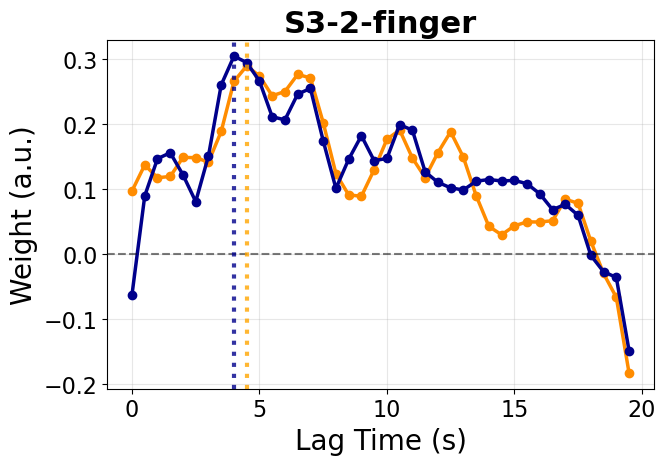

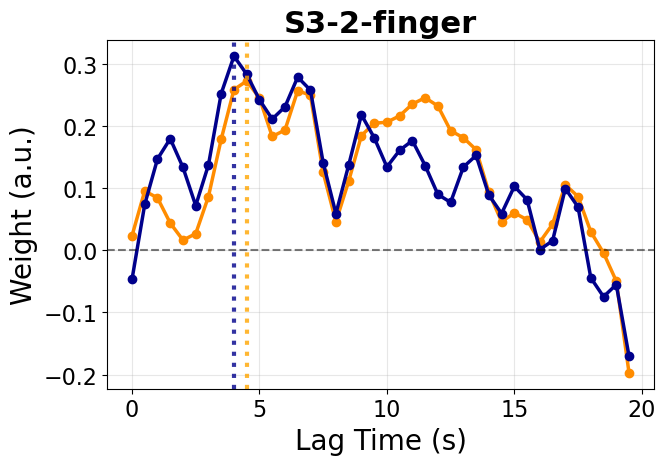

In [ ]:
plot_temporal_weights(wt_hbo_c1, wt_hbr_c1, time_shifts, optimal_lag_hbo_c1, optimal_lag_hbr_c1, meas_id)
plot_temporal_weights(wt_hbo_c2, wt_hbr_c2,time_shifts, optimal_lag_hbo_c2, optimal_lag_hbr_c2, meas_id)


# Spatial Pattern

In [ ]:
Ax_hbo = compute_spatial_pattern(X_train, full_model.Wx.values)
Ay_hbo = compute_spatial_pattern(Y_train, full_model.Wy.values) 
Ax_hbr = compute_spatial_pattern(X_train_hbr, full_model_hbr.Wx.values) 
Ay_hbr = compute_spatial_pattern(Y_train_hbr, full_model_hbr.Wy.values) 

## Figure 6,7

In [ ]:
# Select the component 
plot_spatial_patterns(Ax_hbo.sel(mSPoC_Component='1'), 
                            Ay_hbo.sel(mSPoC_Component='1'), 
                            Ax_hbr.sel(mSPoC_Component='1'), 
                            Ay_hbr.sel(mSPoC_Component='1'), 
                            delay_hbo=optimal_lag_hbo_c1, 
                            delay_hbr=optimal_lag_hbr_c1)
                            

In [ ]:
plot_brain_maps_grid(Ax_hbo.sel(mSPoC_Component='1'),
                        Ay_hbo.sel(mSPoC_Component='1'),
                        Ax_hbr.sel(mSPoC_Component='1'),
                        Ay_hbr.sel(mSPoC_Component='1'), 
                        head_ras, 
                        parcel_list)


# Calculate SNR

In [ ]:
# Compute epoch-based variance for MEG (Matches the fNIRS time grid)
epoch_len = len(X.time) // len(fnirs_final.time)

# zero-mean vector-valued time series
meg_values = X.values - X.values.mean(axis=0)

# Calculate power as variance within epochs
p_power_all = np.array([
    np.var(meg_values[j * epoch_len : (j + 1) * epoch_len], axis=0) # Added axis=0
    for j in range(len(hbo_roi))
])

p_power_xr = xr.DataArray(
    p_power_all,
    coords={
        "time": hbo_roi.time.values, 
        "parcel": X_loaded.parcel.values # Keeps the 17 parcel names
    },
    dims=["time", "parcel"],
    name="MEG_Beta_Power"
)

p_power_xr = p_power_xr.assign_coords(
    samples=("time", np.arange(len(p_power_xr.time)))
)

meg_for_snr = p_power_xr.transpose("parcel","time")
snr_meg_conv = calculate_single_trial_snr(meg_for_snr, stim, bad_trial_indices, is_power=True)


In [ ]:
dot_for_snr = Y.transpose("chromo","parcel","time")
dot_for_snr.time.attrs["units"] = "s" 
dot_for_snr.attrs["units"] = "micromolar" 
snr_hemo_conv = calculate_single_trial_snr(dot_for_snr, stim,bad_trial_indices, is_power=False)


In [ ]:

# get the original, trigger-aligned signal for SNR
full_model_hbo.shift_source = False
full_model_hbr.shift_source = False
Sx_hbo, Sy_hbo = full_model_hbo.transform(X_train_hbo, Y_train_hbo)
Sx_hbr, Sy_hbr = full_model_hbr.transform(X_train_hbr, Y_train_hbr)

Sx_hbo = Sx_hbo.assign_coords(samples=("time", np.arange(len(Sx_hbo.time))))
Sx_hbr = Sx_hbr.assign_coords(samples=("time", np.arange(len(Sx_hbr.time))))
Sy_hbo = Sy_hbo.assign_coords(samples=("time", np.arange(len(Sy_hbo.time))))
Sy_hbr = Sy_hbr.assign_coords(samples=("time", np.arange(len(Sy_hbr.time))))

snr_sx_hbo = calculate_single_trial_snr(Sx_hbo, stim, bad_trial_indices, is_power=True)                              
snr_sx_hbr = calculate_single_trial_snr(Sx_hbr, stim, bad_trial_indices, is_power=True)
snr_sy_hbo = calculate_single_trial_snr(Sy_hbo, stim, bad_trial_indices, is_power=False)
snr_sy_hbr = calculate_single_trial_snr(Sy_hbr, stim, bad_trial_indices, is_power=False)
